In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 8** - maximizing 8D black-box function

- Here we are optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown.

- **Objective** - find the parameter combination that maximises the function’s output, such as _performance_, _efficiency_ or _validation accuracy_.
  - Because the function is high-dimensional and likely complex, global optimisation is hard, so **identifying strong local maxima** is often a practical strategy.

- **For example**, imagine you’re tuning an ML model with eight hyperparameters:
  - learning rate
  - batch size
  - number of layers
  - dropout rate
  - regularisation strength
  - activation function (numerically encoded)
  - optimiser type (encoded)
  - initial weight range.

Each input set returns a single validation accuracy score between 0 and 1.

- **Input** - 8D (40,8)
- **Output** - 8D (40,)
- **Goal** - maximise this score


In [2]:
X = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_8\initial_inputs.npy')
Y = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_8\initial_outputs.npy')

### **Random Search**

- I am doing a random search here just to get a gauage of the space.
  - This will enable me to get an even better idea of the parameters impact on the overall model, adding to the already exisiting output and input data we have.


In [3]:
next_query = np.random.uniform(size = 8)
print(next_query)

[0.1500581  0.36877881 0.08538923 0.07329583 0.24502373 0.14460058
 0.21360429 0.9730725 ]


### **Bayesian Optimisation** - Strategic Approach using Expected Improvements (EI)

- I am using Tikhonov regularization for matrix stability.
  - Since validation accuracy is generally consistent for a fixed set of hyperparameters, we keep noise low to ensure high fidelity to the 40 data points while maintaining numerical stability.

- From some basic research I found out that the Matérn 5/2 kernel is the industry standard for high-dimensional ML tuning because it captures "discrete cliffs" and sharp changes better than the over-smooth RBF kernel.


In [4]:
kernel = Matern(length_scale=[0.5]*8, length_scale_bounds=(1e-3, 2.0), nu=2.5)

model = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=1e-5,
    n_restarts_optimizer=40, 
    normalize_y=True,
    random_state=42
)

model.fit(X, Y)

c:\Users\Pratham\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Pratham\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Pratham\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 5 of parameter length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Pratham\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWar

GaussianProcessRegressor(alpha=1e-05,
                         kernel=Matern(length_scale=[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], nu=2.5),
                         n_restarts_optimizer=40, normalize_y=True,
                         random_state=42)

### **Acquisition Function** - Expected Improvement

- Unlike other functions (like UCB), standard EI does not require tuning internal hyperparameters, making it more robust when data is sparse

- I have decided to use numerically stable formulation (LogEI) to compute the logarithm of improvement directly.
  - This allows the optimizer to "see" and target improvements which are small that would otherwise be invisible, preventing the search from reverting to random sampling.

- Additionally, we evaluate 500,000 points to ensure coverage of the 8D volume.


In [6]:
def expected_improvement(X_grid, model, y_max, xi=0.01):
    mu, sigma = model.predict(X_grid, return_std=True)
    mu, sigma = mu.reshape(-1, 1), sigma.reshape(-1, 1)
    
    with np.errstate(divide='ignore', invalid = 'ignore'):
        imp = mu - y_max - xi
        Z = imp / (sigma + 1e-9)
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0
    return ei.ravel()

x_grid = np.random.uniform(0, 1, size=(500000, 8))
y_max = np.max(Y)
ei_values = expected_improvement(x_grid, model, y_max)

best_idx = np.argmax(ei_values)
next_query = x_grid[best_idx]

print(f"Next Submission for Function 8 - Bayesian Optimisation (EI): "
        f"{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}-{next_query[5]:.6f}-{next_query[6]:.6f}-{next_query[7]:.6f}")

Next Submission for Function 8 - Bayesian Optimisation (EI): 0.120916-0.120905-0.215449-0.155284-0.897467-0.487449-0.153842-0.408101


### **Visualisation of the progress for different inputs**


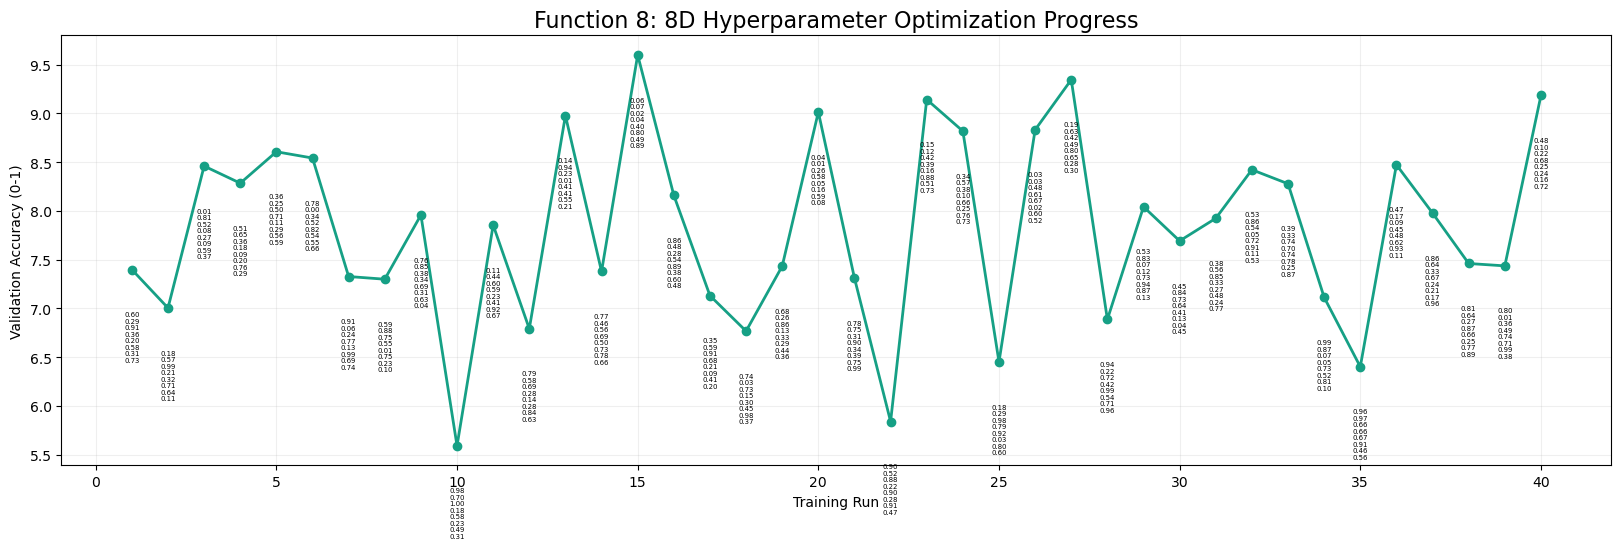

In [8]:
iterations = np.arange(1, len(Y) + 1)
plt.figure(figsize=(20, 10))
plt.plot(iterations, Y, marker='o', color='#16a085', linewidth=2)

for i in range(len(Y)):
    label = "\n".join([f"{val:.2f}" for val in X[i]])
    
    plt.annotate(label, 
                 (iterations[i], Y[i]), 
                 textcoords="offset points", 
                 xytext=(0, -30), 
                 va='top', 
                 ha='center', 
                 fontsize=5,
                 linespacing=1.1)

plt.title("Function 8: 8D Hyperparameter Optimization Progress", fontsize=16)
plt.ylabel("Validation Accuracy (0-1)")
plt.xlabel("Training Run")
plt.subplots_adjust(bottom=0.45) 
plt.grid(True, alpha=0.2)
plt.show()

### **Reasons for having a different input values for week 1 than what is shown here**

**Final Decision** - Due to inability of going through this process in time for week 1 submission I choose the input points which were purely based on exploration.

- **Hence the input for week 1** - [0.007838-0.337307-0.164679-0.407388-0.632409-0.551169-0.306982-0.502300]

- I will be using this thinking process and methodology moving forward into week 2.
